In [1]:
%pip install scipy

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('battery_data.csv')
df['HOUR_TIMESTAMP'] = pd.to_datetime(df['HOUR_TIMESTAMP'])
df = df.sort_values(['CHASSI_NO', 'BATTERY_PACK', 'HOUR_TIMESTAMP']).reset_index(drop=True)

print(f"Shape: {df.shape}")
print(f"Chassis': {sorted(df['CHASSI_NO'].unique())}")
print(f"Pack ids: {sorted(df['BATTERY_PACK'].unique())}")
print(f"Date rang: {df['HOUR_TIMESTAMP'].min().date()} → {df['HOUR_TIMESTAMP'].max().date()}")
print(f"Nulls:\n{df.isnull().sum()}")
df.head()

Shape: (7458, 6)
Chassis': [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
Pack ids: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
Date rang: 2025-09-01 → 2025-09-30
Nulls:
CHASSI_NO                           0
HOUR_TIMESTAMP                      0
BATTERY_PACK                        0
ACCUMULATED_DISCHARGED_ENERGY_WH    0
LAT                                 0
LNG                                 0
dtype: int64


,CHASSI_NO,HOUR_TIMESTAMP,BATTERY_PACK,ACCUMULATED_DISCHARGED_ENERGY_WH,LAT,LNG
0,1,2025-09-01 05:00:00,1,18900.0,59.3293,18.0686
1,1,2025-09-01 06:00:00,1,18900.0,59.3293,18.0686
2,1,2025-09-01 07:00:00,1,18900.0,59.3293,18.0686
3,1,2025-09-01 08:00:00,1,18900.0,59.3293,18.0686
4,1,2025-09-01 09:00:00,1,19000.0,59.3293,18.0686


## Feature Engineering

In [3]:
# Hourly energy delta per (vehicle, pack)
df['ENERGY_DELTA_WH'] = (
    df.groupby(['CHASSI_NO', 'BATTERY_PACK'])['ACCUMULATED_DISCHARGED_ENERGY_WH']
    .diff()
)

df['date']       = df['HOUR_TIMESTAMP'].dt.date
df['hour']       = df['HOUR_TIMESTAMP'].dt.hour
df['dayofweek']  = df['HOUR_TIMESTAMP'].dt.dayofweek  # 0 = Monday
df['is_weekend'] = df['dayofweek'].isin([5, 6])

# drop NaN (first row per group) and negative deltas (counter resets)
valid = df[(df['ENERGY_DELTA_WH'] >= 0) & df['ENERGY_DELTA_WH'].notna()].copy()

print(f"Total rows        : {len(df):,}")
print(f"Valid delta rows  : {len(valid):,}")
print(f"Negative deltas   : {(df['ENERGY_DELTA_WH'] < 0).sum()}  ← counter reset events")

Total rows        : 7,458
Valid delta rows  : 7,427
Negative deltas   : 6  ← counter reset events


In [4]:
for v in [2, 4]:
    pivot = (df[df['CHASSI_NO'] == v]
             .pivot(index='HOUR_TIMESTAMP', columns='BATTERY_PACK',
                    values='ACCUMULATED_DISCHARGED_ENERGY_WH'))
    all_same = (pivot.nunique(axis=1) == 1).all()
    print(f"Vehicle {v} — all 6 packs identical at every timestamp: {all_same}")

Vehicle 2 — all 6 packs identical at every timestamp: True
Vehicle 4 — all 6 packs identical at every timestamp: True


### For Pack id 0 for Vehicle 3 only

In [5]:
pack0 = df[df['BATTERY_PACK'] == 0]
print(f"Rows with BATTERY_PACK=0 : {len(pack0)}")
print(f"Vehicle(s) affected      : {pack0['CHASSI_NO'].unique()}")
print(f"Dates                    : {pack0['HOUR_TIMESTAMP'].dt.date.unique()}")
print()
print("Energy values (Wh):")
print(pack0[['HOUR_TIMESTAMP', 'ACCUMULATED_DISCHARGED_ENERGY_WH']].to_string(index=False))

Rows with BATTERY_PACK=0 : 20
Vehicle(s) affected      : [3]
Dates                    : [datetime.date(2025, 9, 9)]

Energy values (Wh):
     HOUR_TIMESTAMP  ACCUMULATED_DISCHARGED_ENERGY_WH
2025-09-09 04:00:00                        14758900.0
2025-09-09 05:00:00                        14771200.0
2025-09-09 06:00:00                        14774500.0
2025-09-09 07:00:00                        14787100.0
2025-09-09 08:00:00                        14797400.0
2025-09-09 09:00:00                        14805500.0
2025-09-09 10:00:00                        14806400.0
2025-09-09 11:00:00                        14819400.0
2025-09-09 12:00:00                        14826700.0
2025-09-09 13:00:00                        14829700.0
2025-09-09 14:00:00                        14843900.0
2025-09-09 15:00:00                        14858700.0
2025-09-09 16:00:00                        14871200.0
2025-09-09 17:00:00                        14876700.0
2025-09-09 18:00:00                        14887600.0

### Counter reset forVehicle 4, Sep 17

In [6]:
neg = df[df['ENERGY_DELTA_WH'] < 0][
    ['CHASSI_NO','BATTERY_PACK','HOUR_TIMESTAMP',
     'ACCUMULATED_DISCHARGED_ENERGY_WH','ENERGY_DELTA_WH']
]
print(neg.to_string(index=False))

 CHASSI_NO  BATTERY_PACK HOUR_TIMESTAMP  ACCUMULATED_DISCHARGED_ENERGY_WH  ENERGY_DELTA_WH
         4             1     2025-09-17                        10551200.0        -829200.0
         4             2     2025-09-17                        10551200.0        -829200.0
         4             3     2025-09-17                        10551200.0        -829200.0
         4             4     2025-09-17                        10551200.0        -829200.0
         4             5     2025-09-17                        10551200.0        -829200.0
         4             6     2025-09-17                        10551200.0        -829200.0


### Coverage

In [7]:
print(f"{'Vehicle':<10} {'Reported hrs':>14} {'Expected hrs':>14} {'Coverage':>10}")
print("-" * 50)
for v in sorted(df['CHASSI_NO'].unique()):
    p1 = df[(df['CHASSI_NO'] == v) & (df['BATTERY_PACK'] == 1)]
    expected = len(pd.date_range(p1['HOUR_TIMESTAMP'].min(),
                                 p1['HOUR_TIMESTAMP'].max(), freq='h'))
    reported = len(p1)
    print(f"V{v:<9} {reported:>14,} {expected:>14,} {100*reported/expected:>9.0f}%")

Vehicle      Reported hrs   Expected hrs   Coverage
--------------------------------------------------
V1                    302            715        42%
V2                    444            720        62%
V3                    182            710        26%
V4                    315            715        44%


### Total energy consumption per vehicle

In [8]:
# De-duplicate V2 & V4 (use pack 1 × 6 as proxy)
def vehicle_daily(v):
    vv = valid[valid['CHASSI_NO'] == v].copy()
    if v in [2, 4]:
        vv = vv[vv['BATTERY_PACK'] == 1].copy()
        vv['ENERGY_DELTA_WH'] = vv['ENERGY_DELTA_WH'] * 6
    return vv

all_dates = [d.date() for d in pd.date_range('2025-09-01', '2025-09-30')]

print(f"{'Vehicle':<12} {'Total kWh':>12} {'Active days':>13} {'Avg kWh/day':>14}")
print("-" * 55)
for v in [1, 2, 3, 4]:
    vv = vehicle_daily(v)
    total      = vv['ENERGY_DELTA_WH'].sum() / 1000
    active_d   = vv[vv['ENERGY_DELTA_WH'] > 0]['date'].nunique()
    print(f"V{v:<10} {total:>12,.0f} {active_d:>13} {total/active_d:>14,.0f}")

Vehicle         Total kWh   Active days    Avg kWh/day
-------------------------------------------------------
V1                 8,301            21            395
V2                17,213            23            748
V3                13,261            15            884
V4                 8,296            17            488


### Daily consumption over time

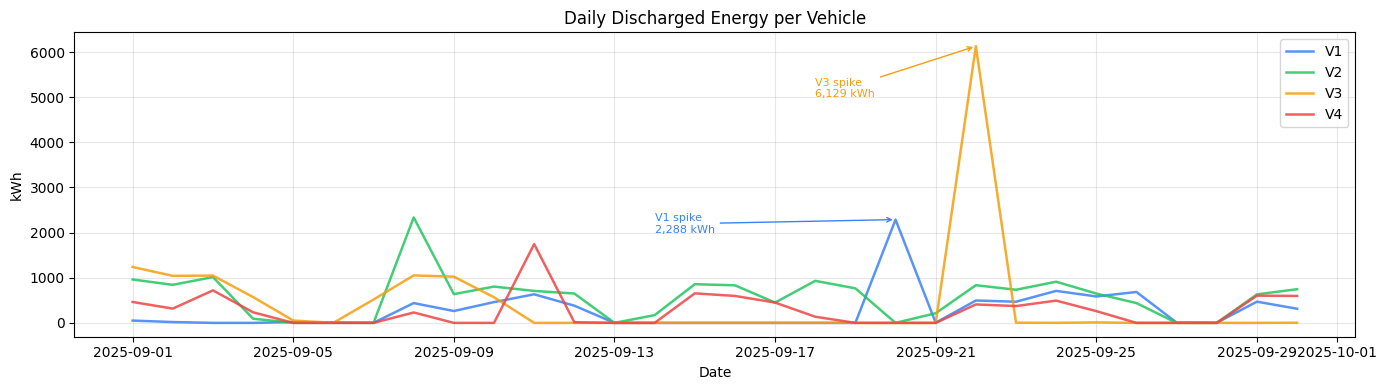

In [9]:
COLORS = {1:'#3B82F6', 2:'#22C55E', 3:'#F59E0B', 4:'#EF4444'}

fig, ax = plt.subplots(figsize=(14, 4))

for v in [1, 2, 3, 4]:
    vv = vehicle_daily(v)
    daily = (vv.groupby('date')['ENERGY_DELTA_WH'].sum()
               .reindex(all_dates).fillna(0) / 1000)
    ax.plot(pd.to_datetime(daily.index), daily.values,
            color=COLORS[v], linewidth=1.8, label=f'V{v}', alpha=0.85)

# Annotate known spikes
ax.annotate('V3 spike\n6,129 kWh', xy=(pd.Timestamp('2025-09-22'), 6129),
            xytext=(pd.Timestamp('2025-09-18'), 5000),
            arrowprops=dict(arrowstyle='->', color='#F59E0B'), color='#F59E0B', fontsize=8)
ax.annotate('V1 spike\n2,288 kWh', xy=(pd.Timestamp('2025-09-20'), 2288),
            xytext=(pd.Timestamp('2025-09-14'), 2000),
            arrowprops=dict(arrowstyle='->', color='#3B82F6'), color='#3B82F6', fontsize=8)

ax.set_ylabel('kWh'); ax.set_xlabel('Date')
ax.set_title('Daily Discharged Energy per Vehicle')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Hourly consumption profile & weekday vs weekend

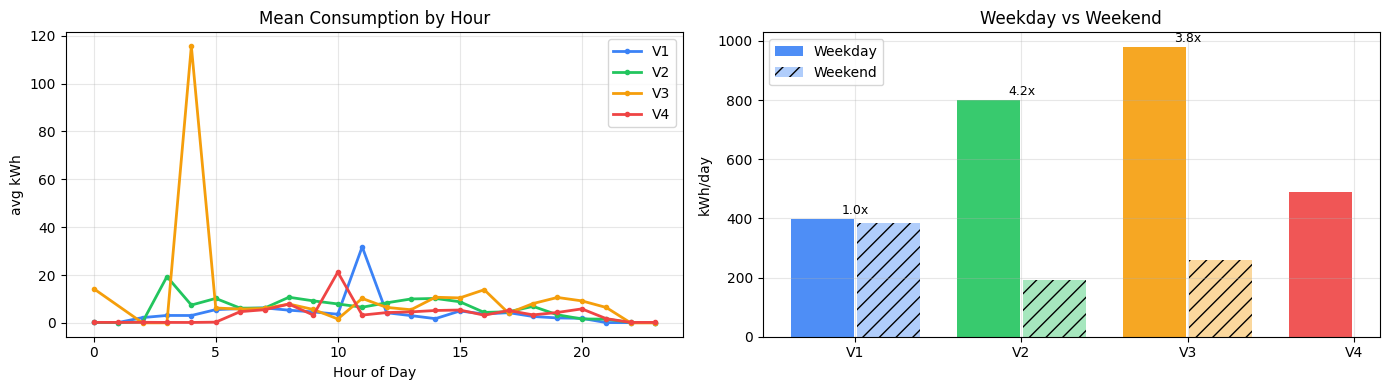

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: avg kWh by hour of day
ax = axes[0]
for v in [1, 2, 3, 4]:
    hr = valid[valid['CHASSI_NO']==v].groupby('hour')['ENERGY_DELTA_WH'].mean() / 1000
    ax.plot(hr.index, hr.values, color=COLORS[v], linewidth=2,
            label=f'V{v}', marker='o', markersize=3)
ax.set_xlabel('Hour of Day'); ax.set_ylabel('avg kWh')
ax.set_title('Mean Consumption by Hour'); ax.legend(); ax.grid(alpha=0.3)

# Right: weekday vs weekend avg daily kWh
ax2 = axes[1]
wd_vals, we_vals = [], []
for v in [1, 2, 3, 4]:
    vv = vehicle_daily(v)
    grp = vv.groupby(['date','is_weekend'])['ENERGY_DELTA_WH'].sum() / 1000
    wd_vals.append(grp[~grp.index.get_level_values('is_weekend')].mean())
    we_vals.append(grp[ grp.index.get_level_values('is_weekend')].mean())

x = np.arange(4)
ax2.bar(x - 0.2, wd_vals, 0.38, color=[COLORS[v] for v in [1,2,3,4]], label='Weekday', alpha=0.9)
ax2.bar(x + 0.2, we_vals, 0.38, color=[COLORS[v] for v in [1,2,3,4]], label='Weekend',
        alpha=0.4, hatch='//')
for i, (wd, we) in enumerate(zip(wd_vals, we_vals)):
    if we and we > 0:
        ax2.text(i, max(wd, we) + 15, f'{wd/we:.1f}x', ha='center', fontsize=9)
ax2.set_xticks(x); ax2.set_xticklabels(['V1','V2','V3','V4'])
ax2.set_ylabel('kWh/day'); ax2.set_title('Weekday vs Weekend'); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout(); plt.show()

## V1 & V3 only 

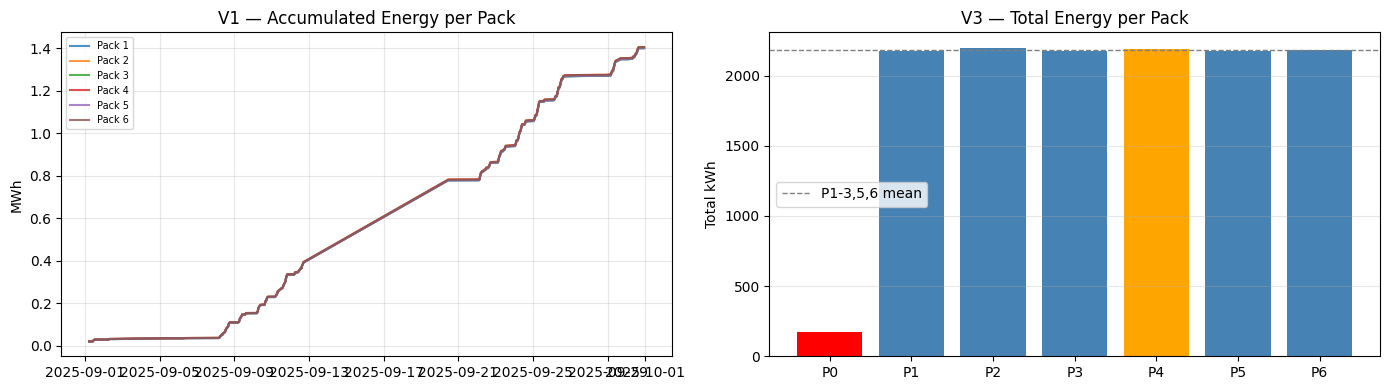

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# V1 — pack divergence over time
ax = axes[0]
v1 = df[df['CHASSI_NO']==1].sort_values('HOUR_TIMESTAMP')
for p in [1,2,3,4,5,6]:
    vp = v1[v1['BATTERY_PACK']==p]
    ax.plot(vp['HOUR_TIMESTAMP'], vp['ACCUMULATED_DISCHARGED_ENERGY_WH']/1e6,
            linewidth=1.5, alpha=0.8, label=f'Pack {p}')
ax.set_ylabel('MWh'); ax.set_title('V1 — Accumulated Energy per Pack')
ax.legend(fontsize=7); ax.grid(alpha=0.3)

# V3 — pack total comparison including pack 0
ax2 = axes[1]
v3_totals = (valid[valid['CHASSI_NO']==3]
             .groupby('BATTERY_PACK')['ENERGY_DELTA_WH'].sum() / 1000)
bar_colors = ['red' if p == 0 else ('orange' if p == 4 else 'steelblue')
              for p in v3_totals.index]
ax2.bar([f'P{p}' for p in v3_totals.index], v3_totals.values,
        color=bar_colors, edgecolor='none')
ax2.axhline(v3_totals[[1,2,3,5,6]].mean(), linestyle='--', color='gray',
            linewidth=1, label='P1-3,5,6 mean')
ax2.set_ylabel('Total kWh'); ax2.set_title('V3 — Total Energy per Pack')
ax2.legend(); ax2.grid(alpha=0.3, axis='y')

plt.tight_layout(); plt.show()
